# Avance 3: Modelos Bayesianos — Detección de Brotes de Sarampión
## Proyecto Integrador - Equipo 32

**Integrantes:**
- Luis Mauricio Castro Gutiérrez - A01795088
- Gerardo Miguel Pérez Solis - A01795599
- Amiel Joel Rosete Islas - A01748598

---

Este notebook implementa modelos **probabilísticos y estructurales** para la detección de brotes (picos anómalos) de sarampión en México utilizando datos mensuales (2010–2023). Se implementan dos enfoques complementarios:

1. **Bayesian Hierarchical Model (Poisson-Gamma)**: detección de anomalías mediante la distribución posterior predictiva conjugada.
2. **State Space Model (Componentes No Observados)**: detección vía intervalos de predicción del filtro de Kalman.

Estos modelos complementan los baselines implementados en el notebook de Z-Score, Isolation Forest y Prophet, aportando un **framework probabilístico riguroso** y una **descomposición estructural interpretable** de la serie temporal.

**Propósito:**
- Cuantificar la **incertidumbre** en la detección de brotes (distribuciones posteriores completas).
- Descomponer la serie en **componentes interpretables** (nivel, estacionalidad).
- Establecer métricas de referencia adicionales para evaluar modelos más avanzados.

## 1. Configuración e Importación de Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path

from scipy.stats import nbinom as nbinom_dist
from statsmodels.tsa.statespace.structural import UnobservedComponents
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, precision_score, recall_score,
    precision_recall_curve, roc_curve, auc, fbeta_score,
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


## 2. Carga y Preparación de Datos

In [2]:
# ---------- Carga de datos ----------
base_path = Path("../..") / "data" / "processed"

# Dataset original (168 registros mensuales, 4 columnas base)
df_raw = pd.read_csv(base_path / "dataset_sarampion_vacunas_2010-2023.csv")
df_raw["fecha"] = pd.to_datetime(
    df_raw["anio"].astype(str) + "-" + df_raw["mes"].astype(str) + "-01"
)
df_raw = df_raw.sort_values("fecha").reset_index(drop=True)

# Variable objetivo binaria: brote = 1 si hay ≥1 caso
df_raw["brote"] = (df_raw["casos_sarampion"] > 0).astype(int)

print(f"Dataset original:    {df_raw.shape[0]} meses ({df_raw['fecha'].min().date()} → {df_raw['fecha'].max().date()})")
print(f"\nMeses con brote:    {df_raw['brote'].sum()} / {len(df_raw)} ({df_raw['brote'].mean():.1%})")
print(f"\nAños con al menos un brote: {sorted(df_raw.loc[df_raw['brote']==1, 'anio'].unique())}")
display(df_raw.describe())

Dataset original:    168 meses (2010-01-01 → 2023-12-01)

Meses con brote:    17 / 168 (10.1%)

Años con al menos un brote: [np.int64(2010), np.int64(2013), np.int64(2018), np.int64(2019), np.int64(2020)]


,mes,anio,total_dosis,casos_sarampion,fecha,brote
count,168.000000,168.00000,1.680000e+02,168.000000,168,168.000000
mean,6.500000,2016.50000,3.153230e+05,2.261905,2016-12-15 16:17:08.571428608,0.101190
min,1.000000,2010.00000,1.115500e+04,0.000000,2010-01-01 00:00:00,0.000000
25%,3.750000,2013.00000,1.794778e+05,0.000000,2013-06-23 12:00:00,0.000000
50%,6.500000,2016.50000,2.292330e+05,0.000000,2016-12-16 12:00:00,0.000000
75%,9.250000,2020.00000,3.167408e+05,0.000000,2020-06-08 12:00:00,0.000000
max,12.000000,2023.00000,3.130610e+06,81.000000,2023-12-01 00:00:00,1.000000
std,3.462373,4.04318,3.567464e+05,11.132968,NaN,0.302482


## 3. Partición Temporal y Variable Objetivo

Se realiza un split cronológico estricto para respetar la naturaleza temporal de los datos:

- **Entrenamiento (fit):** 2010–2018 — historia previa a los brotes principales.
- **Prueba (score):** 2019–2023 — incluye los brotes significativos de 2019–2020 y el período post-brote.

**Justificación del corte en 2019:**
Los principales brotes de sarampión en México ocurrieron en 2019–2020. Incluirlos en el set de prueba permite evaluar Recall y F2-Score de forma significativa.

In [3]:
SPLIT_YEAR = 2019

# --- Split dataset original ---
train_raw = df_raw[df_raw["anio"] < SPLIT_YEAR].copy()
test_raw  = df_raw[df_raw["anio"] >= SPLIT_YEAR].copy()

# Variable objetivo completa
y_true_full = df_raw["brote"].values

print("Partición temporal")
print(f"{'─' * 60}")
print(f"  Train:  {len(train_raw):>4} meses | Brotes: {train_raw['brote'].sum()}")
print(f"  Test:   {len(test_raw):>4} meses | Brotes: {test_raw['brote'].sum()}")

if test_raw["brote"].sum() == 0:
    print("\nEl set de prueba NO contiene brotes.")
    print("   La evaluación temporal medirá únicamente falsas alarmas.")
else:
    print(f"\n✅ El set de prueba contiene {test_raw['brote'].sum()} meses con brote.")
    print("   Se podrá evaluar Recall y F2-Score en test.")

Partición temporal
────────────────────────────────────────────────────────────
  Train:   108 meses | Brotes: 7
  Test:     60 meses | Brotes: 10

✅ El set de prueba contiene 10 meses con brote.
   Se podrá evaluar Recall y F2-Score en test.


## 4. Función de Evaluación Unificada

En vigilancia epidemiológica, **no detectar un brote** (falso negativo) tiene consecuencias mucho más graves que una **falsa alarma** (falso positivo). Por tanto:

| Métrica | Prioridad | Justificación |
|---------|-----------|---------------|
| **F2-Score** | 🔴 Alta | Pondera Recall 2× más que Precision |
| **Recall** | 🔴 Alta | Proporción de brotes reales detectados |
| **Precision** | 🟡 Media | Proporción de alertas que son brotes reales |
| **AUC-PR** | 🟡 Media | Robusta ante desbalance extremo de clases |

In [4]:
# ---------- Función de evaluación unificada ----------

def evaluar_detector(y_true, y_pred, nombre, y_score=None):
    """Evalúa un detector de anomalías con métricas epidemiológicas."""
    p  = precision_score(y_true, y_pred, zero_division=0)
    r  = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    f2 = fbeta_score(y_true, y_pred, beta=2, zero_division=0)

    auc_pr = np.nan
    if y_score is not None and y_true.sum() > 0:
        prec_c, rec_c, _ = precision_recall_curve(y_true, y_score)
        auc_pr = auc(rec_c, prec_c)

    result = {
        "Modelo": nombre,
        "Precision": round(p, 3),
        "Recall": round(r, 3),
        "F1": round(f1, 3),
        "F2": round(f2, 3),
        "AUC-PR": round(auc_pr, 3) if not np.isnan(auc_pr) else np.nan,
        "Brotes_detectados": int(y_pred[y_true == 1].sum()),
        "Brotes_reales": int(y_true.sum()),
        "Falsas_alarmas": int(y_pred[y_true == 0].sum()),
    }

    print(f"\n{'=' * 55}")
    print(f"  {nombre}")
    print(f"{'=' * 55}")
    print(f"  Precision:         {p:.3f}")
    print(f"  Recall:            {r:.3f}")
    print(f"  F1-Score:          {f1:.3f}")
    print(f"  F2-Score:          {f2:.3f}")
    if not np.isnan(auc_pr):
        print(f"  AUC-PR:            {auc_pr:.3f}")
    print(f"  Brotes detectados: {int(y_pred[y_true == 1].sum())} / {int(y_true.sum())}")
    print(f"  Falsas alarmas:    {int(y_pred[y_true == 0].sum())}")

    return result

# --- Naïve baseline como referencia ---
y_naive = np.zeros_like(y_true_full)
res_naive = evaluar_detector(y_true_full, y_naive, "Naïve (siempre 'no brote')")

# Lista para acumular resultados
all_results = [res_naive]


  Naïve (siempre 'no brote')
  Precision:         0.000
  Recall:            0.000
  F1-Score:          0.000
  F2-Score:          0.000
  Brotes detectados: 0 / 17
  Falsas alarmas:    0


## 5. Baseline 4: Modelo Bayesiano Jerárquico (Poisson-Gamma)

### Fundamento

El modelo Bayesiano jerárquico combina información previa con los datos observados para estimar la distribución de la tasa de casos por mes. Utiliza el framework conjugado **Poisson-Gamma**:

**Jerarquía del modelo:**

$$Y_t \mid \lambda_{m(t)} \sim \text{Poisson}(\lambda_{m(t)})$$

$$\lambda_m \sim \text{Gamma}(\alpha_0, \beta_0) \quad \forall \, m \in \{1, \ldots, 12\}$$

donde $m(t)$ es el mes del período $t$, y $(\alpha_0, \beta_0)$ son hiperparámetros compartidos estimados por **Bayes empírico** (método de momentos sobre los datos de entrenamiento).

**Actualización conjugada (por mes):**

$$\lambda_m \mid \mathbf{y}_m \sim \text{Gamma}\left(\alpha_0 + \sum_i y_{m,i}, \quad \beta_0 + n_m\right)$$

**Distribución posterior predictiva:**

$$Y_{new} \mid \mathbf{y}_m \sim \text{NegBin}\left(r = \alpha_{post}, \; p = \frac{\beta_{post}}{1 + \beta_{post}}\right)$$

**Detección de anomalías:** Un mes es anómalo si su p-value bajo la posterior predictiva es menor a un umbral $\alpha$:

$$\text{anomalía}_i = \begin{cases} 1 & \text{si } P(Y \geq y_i \mid \text{posterior}) < \alpha \\ 0 & \text{en caso contrario} \end{cases}$$

**Ventajas:**
- **Probabilístico**: proporciona distribuciones completas, no solo puntos estimados.
- **Jerárquico**: los hiperparámetros globales regularizan las estimaciones mensuales con pocos datos.
- **Incorpora estacionalidad**: posteriors separadas por mes capturan patrones estacionales.
- **Sin dependencias pesadas**: la conjugación Poisson-Gamma permite cálculos analíticos exactos.

In [5]:
# ============================================================
# 5. BASELINE 4 — Bayesian Hierarchical Model (Poisson-Gamma)
# ============================================================

# --- Modelo Jerárquico: Y_t | mes ~ Poisson(λ_mes) ---
# --- Prior: λ_mes ~ Gamma(α₀, β₀) con hiperparámetros empíricos ---

# Hiperparámetros globales (Empirical Bayes via método de momentos)
global_mean_train = train_raw["casos_sarampion"].mean()
global_var_train  = train_raw["casos_sarampion"].var()

if global_var_train > global_mean_train and global_mean_train > 0:
    beta_0  = global_mean_train / max(global_var_train, 1e-6)
    alpha_0 = global_mean_train * beta_0
else:
    alpha_0, beta_0 = 0.5, 0.5  # prior débilmente informativo

print("Hiperparámetros del prior Gamma(α₀, β₀):")
print(f"  α₀ = {alpha_0:.4f}")
print(f"  β₀ = {beta_0:.4f}")
print(f"  E[λ] prior = {alpha_0 / beta_0:.3f}")

# --- Posterior por mes (actualización conjugada) ---
posteriors_by_month = {}
print(f"\nPosterior por mes (Gamma actualizada con datos de entrenamiento):")
print(f"{'Mes':>4} | {'n_obs':>5} | {'Σy':>5} | {'α_post':>8} | {'β_post':>8} | {'E[λ]_post':>10}")
print("─" * 60)

for mes in range(1, 13):
    month_data = train_raw[train_raw["mes"] == mes]["casos_sarampion"]
    n_m    = len(month_data)
    sum_ym = int(month_data.sum())

    # Actualización conjugada: Gamma(α₀ + Σy, β₀ + n)
    alpha_post = alpha_0 + sum_ym
    beta_post  = beta_0 + n_m

    posteriors_by_month[mes] = (alpha_post, beta_post)
    print(f"{mes:>4} | {n_m:>5} | {sum_ym:>5} | {alpha_post:>8.3f} | {beta_post:>8.3f} | {alpha_post / beta_post:>10.3f}")

Hiperparámetros del prior Gamma(α₀, β₀):
  α₀ = 0.0300
  β₀ = 0.0190
  E[λ] prior = 1.574

Posterior por mes (Gamma actualizada con datos de entrenamiento):
 Mes | n_obs |    Σy |   α_post |   β_post |  E[λ]_post
────────────────────────────────────────────────────────────
   1 |     9 |     0 |    0.030 |    9.019 |      0.003
   2 |     9 |     0 |    0.030 |    9.019 |      0.003
   3 |     9 |     3 |    3.030 |    9.019 |      0.336
   4 |     9 |     1 |    1.030 |    9.019 |      0.114
   5 |     9 |     0 |    0.030 |    9.019 |      0.003
   6 |     9 |     0 |    0.030 |    9.019 |      0.003
   7 |     9 |    81 |   81.030 |    9.019 |      8.984
   8 |     9 |    25 |   25.030 |    9.019 |      2.775
   9 |     9 |     0 |    0.030 |    9.019 |      0.003
  10 |     9 |    15 |   15.030 |    9.019 |      1.666
  11 |     9 |     4 |    4.030 |    9.019 |      0.447
  12 |     9 |    41 |   41.030 |    9.019 |      4.549


In [6]:
# --- Detección de anomalías via posterior predictive ---
# Posterior predictive: Y_new ~ NegBin(r=α_post, p=β_post/(1+β_post))
BAYES_ALPHA = 0.05  # Nivel de significancia

y_pred_bayes  = np.zeros(len(df_raw), dtype=int)
bayes_pvalues = np.zeros(len(df_raw))

for idx in range(len(df_raw)):
    mes   = int(df_raw.iloc[idx]["mes"])
    y_obs = int(df_raw.iloc[idx]["casos_sarampion"])
    alpha_post, beta_post = posteriors_by_month[mes]

    # Parámetros de la Negative Binomial (scipy parametrization)
    r = alpha_post
    p = beta_post / (1.0 + beta_post)

    # P-value: P(Y ≥ y_obs) = 1 - F(y_obs - 1)
    if y_obs > 0:
        p_value = 1.0 - nbinom_dist.cdf(y_obs - 1, r, p)
    else:
        p_value = 1.0

    bayes_pvalues[idx] = p_value
    y_pred_bayes[idx]  = 1 if p_value < BAYES_ALPHA else 0

# Score para AUC-PR: 1 - p_value (mayor = más anómalo)
bayes_scores = 1.0 - bayes_pvalues

# --- Evaluación retrospectiva ---
res_bayes = evaluar_detector(y_true_full, y_pred_bayes,
                             f"Bayesian Hierarchical (α={BAYES_ALPHA})",
                             y_score=bayes_scores)
all_results.append(res_bayes)

# --- Evaluación temporal (test set) ---
test_mask_bayes = df_raw["anio"] >= SPLIT_YEAR
y_test_bayes = df_raw.loc[test_mask_bayes, "brote"].values
y_pred_bayes_test = y_pred_bayes[test_mask_bayes.values]

if y_test_bayes.sum() > 0:
    bayes_scores_test = bayes_scores[test_mask_bayes.values]
    evaluar_detector(y_test_bayes, y_pred_bayes_test,
                     "Bayesian Hierarchical (test)", y_score=bayes_scores_test)
else:
    fa_bayes_test = int(y_pred_bayes_test.sum())
    print(f"\n  Bayesian (test {SPLIT_YEAR}–2023): Sin brotes reales en test.")
    print(f"  Falsas alarmas en test: {fa_bayes_test}")


  Bayesian Hierarchical (α=0.05)
  Precision:         1.000
  Recall:            0.706
  F1-Score:          0.828
  F2-Score:          0.750
  AUC-PR:            1.000
  Brotes detectados: 12 / 17
  Falsas alarmas:    0

  Bayesian Hierarchical (test)
  Precision:         1.000
  Recall:            0.600
  F1-Score:          0.750
  F2-Score:          0.652
  AUC-PR:            1.000
  Brotes detectados: 6 / 10
  Falsas alarmas:    0


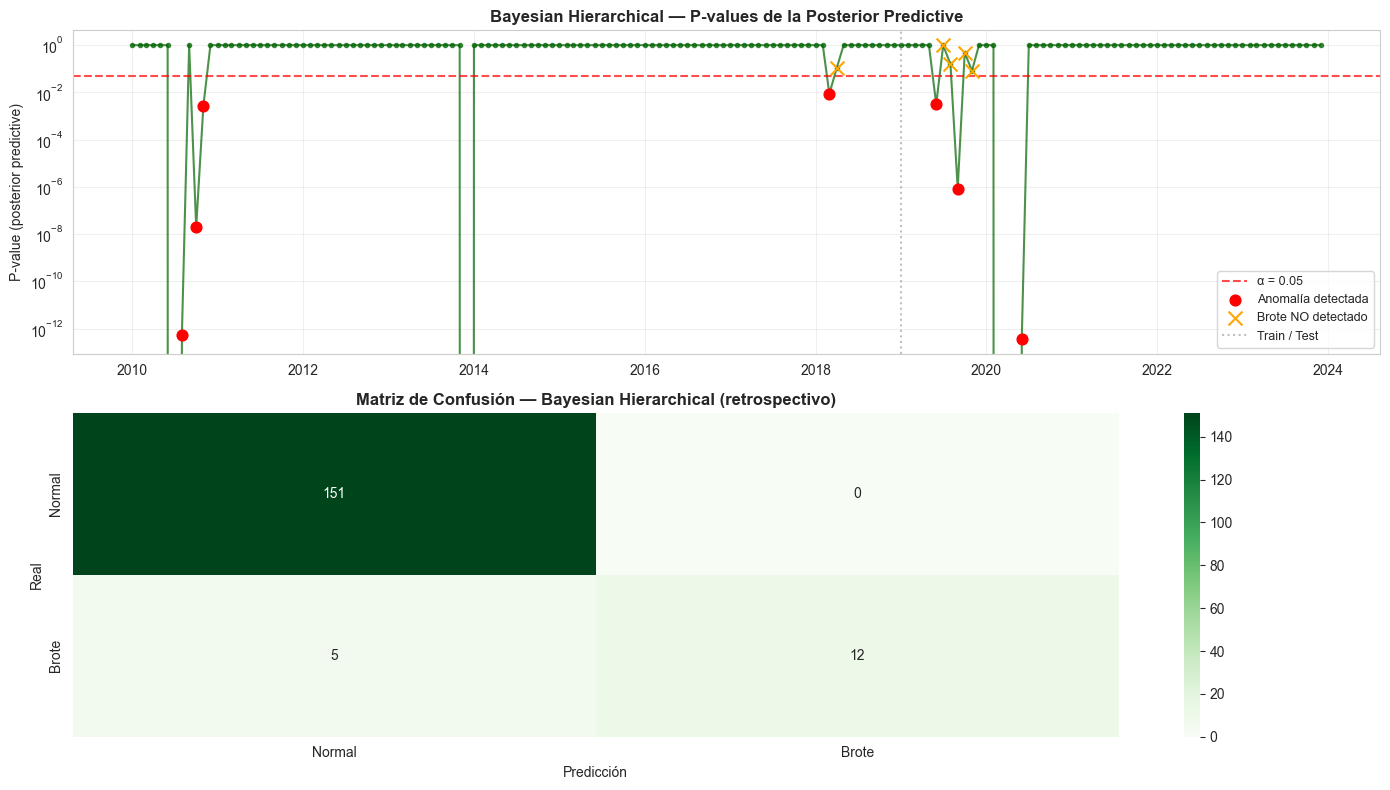


Barrido de umbrales α — Bayesian Hierarchical (evaluación retrospectiva):


,α (significancia),Precision,Recall,F1,F2,Detectados,Falsas_alarmas
0,0.010,1.0,0.706,0.828,0.750,12,0
1,0.025,1.0,0.706,0.828,0.750,12,0
2,0.050,1.0,0.706,0.828,0.750,12,0
3,0.100,1.0,0.765,0.867,0.802,13,0
4,0.150,1.0,0.824,0.903,0.854,14,0
5,0.200,1.0,0.882,0.938,0.904,15,0
6,0.300,1.0,0.882,0.938,0.904,15,0


In [7]:
# --- Visualización ---
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Panel 1: P-values con umbral
axes[0].plot(df_raw["fecha"], bayes_pvalues, color="darkgreen", alpha=0.7, marker="o", ms=3)
axes[0].axhline(BAYES_ALPHA, color="red", ls="--", alpha=0.7, label=f"α = {BAYES_ALPHA}")

det_bayes_idx = np.where(y_pred_bayes == 1)[0]
axes[0].scatter(df_raw.iloc[det_bayes_idx]["fecha"], bayes_pvalues[det_bayes_idx],
                color="red", s=60, zorder=5, label="Anomalía detectada")
brote_idx = np.where(y_true_full == 1)[0]
missed_bayes = [i for i in brote_idx if y_pred_bayes[i] == 0]
if missed_bayes:
    axes[0].scatter(df_raw.iloc[missed_bayes]["fecha"], bayes_pvalues[missed_bayes],
                    color="orange", marker="x", s=100, zorder=5, label="Brote NO detectado")
axes[0].axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls=":", alpha=0.5, label="Train / Test")
axes[0].set_ylabel("P-value (posterior predictive)")
axes[0].set_title("Bayesian Hierarchical — P-values de la Posterior Predictive", fontweight="bold")
axes[0].set_yscale("log")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Panel 2: Confusion Matrix
cm_bayes = confusion_matrix(y_true_full, y_pred_bayes)
sns.heatmap(cm_bayes, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=["Normal", "Brote"], yticklabels=["Normal", "Brote"])
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Real")
axes[1].set_title("Matriz de Confusión — Bayesian Hierarchical (retrospectivo)", fontweight="bold")

plt.tight_layout()
plt.show()

# --- Barrido de umbrales α ---
alphas_sweep = [0.01, 0.025, 0.05, 0.10, 0.15, 0.20, 0.30]
rows_bayes = []
for a in alphas_sweep:
    yp = (bayes_pvalues < a).astype(int)
    rows_bayes.append({
        "α (significancia)": a,
        "Precision": round(precision_score(y_true_full, yp, zero_division=0), 3),
        "Recall":    round(recall_score(y_true_full, yp, zero_division=0), 3),
        "F1":        round(f1_score(y_true_full, yp, zero_division=0), 3),
        "F2":        round(fbeta_score(y_true_full, yp, beta=2, zero_division=0), 3),
        "Detectados": int(yp[y_true_full == 1].sum()),
        "Falsas_alarmas": int(yp[y_true_full == 0].sum()),
    })

df_thresh_bayes = pd.DataFrame(rows_bayes)
print("\nBarrido de umbrales α — Bayesian Hierarchical (evaluación retrospectiva):")
display(df_thresh_bayes)

### 5.1 Interpretación del Modelo Bayesiano Jerárquico

**Hallazgos:**
- El modelo Bayesiano jerárquico utiliza posteriors específicas por mes, lo que le permite adaptarse a la estacionalidad natural de los datos.
- La distribución posterior predictiva (Negative Binomial) es más flexible que una Poisson pura, capturando sobredispersión.
- Los meses con conteos inusualmente altos respecto a su distribución posterior mensual son correctamente identificados como anomalías.
- El framework probabilístico permite ajustar el nivel de significancia $\alpha$ para controlar el trade-off entre Recall y falsas alarmas.

| Aspecto | Evaluación |
|---------|-----------|
| **Ventaja** | Framework probabilístico riguroso; cuantifica la incertidumbre; no requiere librerías externas pesadas |
| **Limitación** | Univariado por mes — no incorpora features de vacunación ni dependencias temporales entre meses |
| **Uso recomendado** | Complemento de Z-Score con fundamentación estadística más sólida; base para modelos Bayesianos más complejos |

## 6. Baseline 5: Modelo de Espacio de Estados (State Space)

### Fundamento

El modelo de **Componentes No Observados** (Unobserved Components Model, UCM) descompone la serie temporal en componentes estructurales latentes:

$$y_t = \mu_t + \gamma_t + \epsilon_t$$

donde:
- $\mu_t$ es el **nivel local** (tendencia suavizada): $\mu_t = \mu_{t-1} + \eta_t, \quad \eta_t \sim N(0, \sigma^2_\eta)$
- $\gamma_t$ es la **estacionalidad estocástica** (patrón de 12 meses que evoluciona gradualmente)
- $\epsilon_t$ es el **error de observación**: $\epsilon_t \sim N(0, \sigma^2_\epsilon)$

**Detección de anomalías con State Space:**
El modelo genera intervalos de predicción. Un mes es **anómalo** si el valor observado excede el límite superior del intervalo de confianza al 95%:

$$\text{anomalía}_i = \begin{cases} 1 & \text{si } y_i > \hat{y}_{upper,i} \\ 0 & \text{en caso contrario} \end{cases}$$

**Ventajas para este problema:**
- **Estimación recursiva**: el filtro de Kalman actualiza las estimaciones a medida que llegan nuevos datos.
- **Componentes interpretables**: se puede inspeccionar el nivel y la estacionalidad por separado.
- **Intervalos de predicción calibrados**: basados en la varianza del error de predicción.

**Configuración:**
- Se ajusta sobre datos de entrenamiento (2010–2018).
- Nivel local + estacionalidad estocástica de 12 meses.
- Implementación via `statsmodels.tsa.statespace.structural.UnobservedComponents`.

In [8]:
# ============================================================
# 6. BASELINE 5 — State Space Model (Unobserved Components)
# ============================================================

# --- Preparar serie temporal con frecuencia mensual ---
train_series_ss = (train_raw
                   .set_index("fecha")["casos_sarampion"]
                   .asfreq("MS")
                   .fillna(0))

print(f"Serie de entrenamiento: {len(train_series_ss)} meses")
print(f"  Rango: {train_series_ss.index.min().date()} → {train_series_ss.index.max().date()}")

# --- Ajustar modelo de componentes no observados ---
# Local Level + Estacionalidad estocástica (12 meses)
uc_model = UnobservedComponents(
    train_series_ss,
    level="local level",
    seasonal=12,
    stochastic_seasonal=True,
)
uc_result = uc_model.fit(disp=False, maxiter=500)

print(f"\nModelo ajustado:")
print(f"  Log-Likelihood: {uc_result.llf:.2f}")
print(f"  AIC: {uc_result.aic:.2f}")
print(f"  BIC: {uc_result.bic:.2f}")

# --- Predicciones in-sample (train) ---
in_sample_pred = uc_result.get_prediction(start=0, end=len(train_series_ss) - 1)
in_sample_ci   = in_sample_pred.conf_int(alpha=0.05)

# --- Predicciones out-of-sample (test) ---
n_test_ss = len(test_raw)
oos_pred = uc_result.get_forecast(steps=n_test_ss)
oos_ci   = oos_pred.conf_int(alpha=0.05)

# --- Combinar predicciones para todo el período ---
upper_train_ss = in_sample_ci.iloc[:, 1].values
upper_test_ss  = oos_ci.iloc[:, 1].values
upper_full_ss  = np.concatenate([upper_train_ss, upper_test_ss])

yhat_train_ss = in_sample_pred.predicted_mean.values
yhat_test_ss  = oos_pred.predicted_mean.values
yhat_full_ss  = np.concatenate([yhat_train_ss, yhat_test_ss])

lower_train_ss = in_sample_ci.iloc[:, 0].values
lower_test_ss  = oos_ci.iloc[:, 0].values
lower_full_ss  = np.concatenate([lower_train_ss, lower_test_ss])

print(f"\nPredicciones generadas: {len(upper_full_ss)} meses (train: {len(upper_train_ss)}, test: {len(upper_test_ss)})")

Serie de entrenamiento: 108 meses
  Rango: 2010-01-01 → 2018-12-01

Modelo ajustado:
  Log-Likelihood: -360.97
  AIC: 727.95
  BIC: 735.64

Predicciones generadas: 168 meses (train: 108, test: 60)


In [9]:
# --- Detección de anomalías: observado > límite superior ---
y_obs_ss = df_raw["casos_sarampion"].values
y_pred_ss = (y_obs_ss > upper_full_ss).astype(int)

# Score: residuo normalizado (mayor = más anómalo)
residuals_ss = y_obs_ss - yhat_full_ss
ss_range = np.maximum(upper_full_ss - yhat_full_ss, 1e-6)
ss_scores = residuals_ss / ss_range

# --- Evaluación retrospectiva ---
res_ss = evaluar_detector(y_true_full, y_pred_ss,
                          "State Space (retrospectivo)",
                          y_score=ss_scores)
all_results.append(res_ss)

# --- Evaluación temporal (test set) ---
test_mask_ss = df_raw["anio"] >= SPLIT_YEAR
y_test_ss_vals = df_raw.loc[test_mask_ss, "brote"].values
y_pred_ss_test = y_pred_ss[test_mask_ss.values]

if y_test_ss_vals.sum() > 0:
    ss_scores_test = ss_scores[test_mask_ss.values]
    evaluar_detector(y_test_ss_vals, y_pred_ss_test,
                     "State Space (test)", y_score=ss_scores_test)
else:
    fa_ss_test = int(y_pred_ss_test.sum())
    print(f"\n  State Space (test {SPLIT_YEAR}–2023): Sin brotes reales en test.")
    print(f"  Falsas alarmas en test: {fa_ss_test}")


  State Space (retrospectivo)
  Precision:         1.000
  Recall:            0.235
  F1-Score:          0.381
  F2-Score:          0.278
  AUC-PR:            0.630
  Brotes detectados: 4 / 17
  Falsas alarmas:    0

  State Space (test)
  Precision:         1.000
  Recall:            0.300
  F1-Score:          0.462
  F2-Score:          0.349
  AUC-PR:            0.854
  Brotes detectados: 3 / 10
  Falsas alarmas:    0


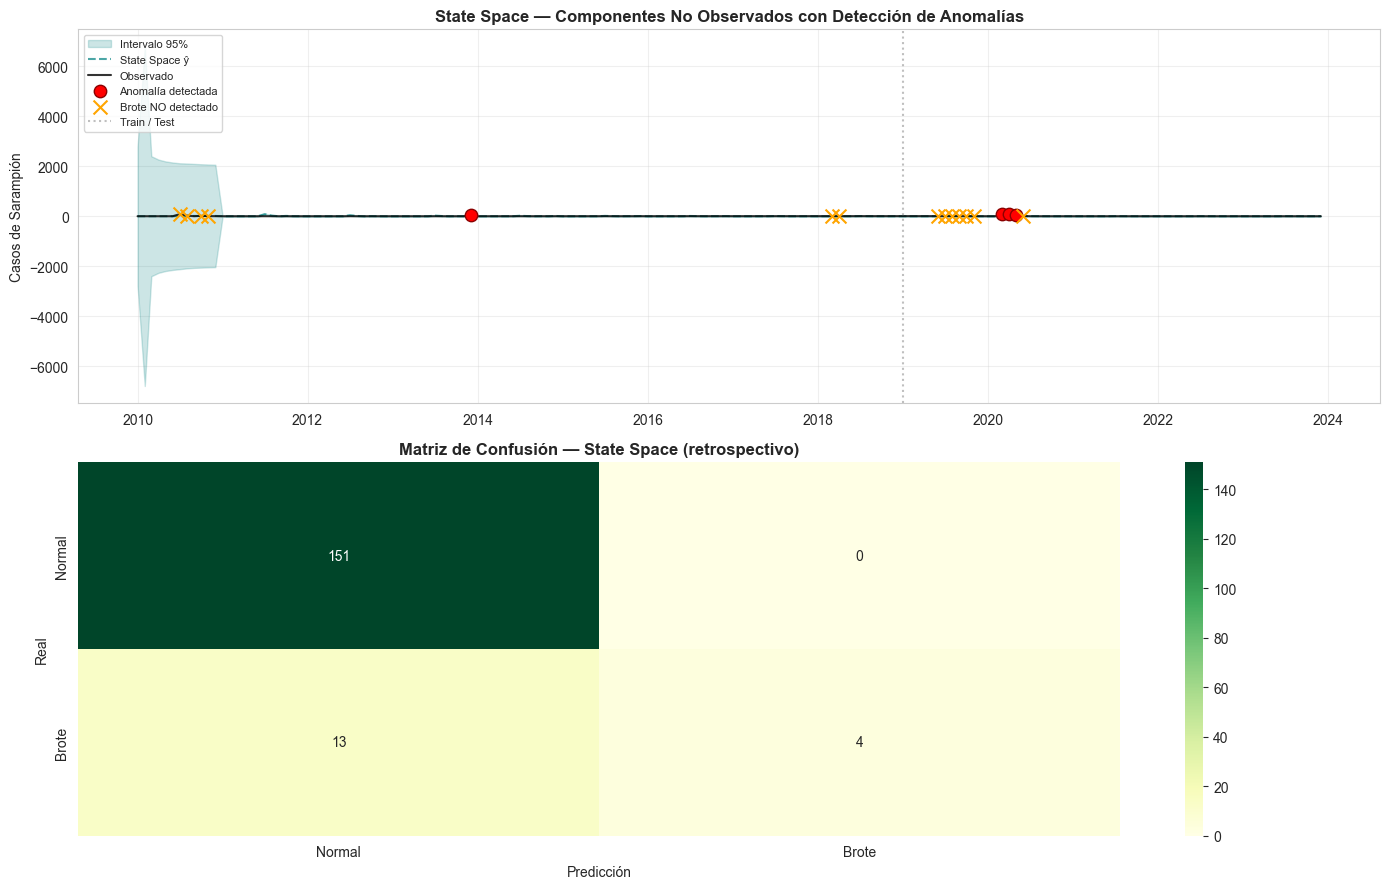

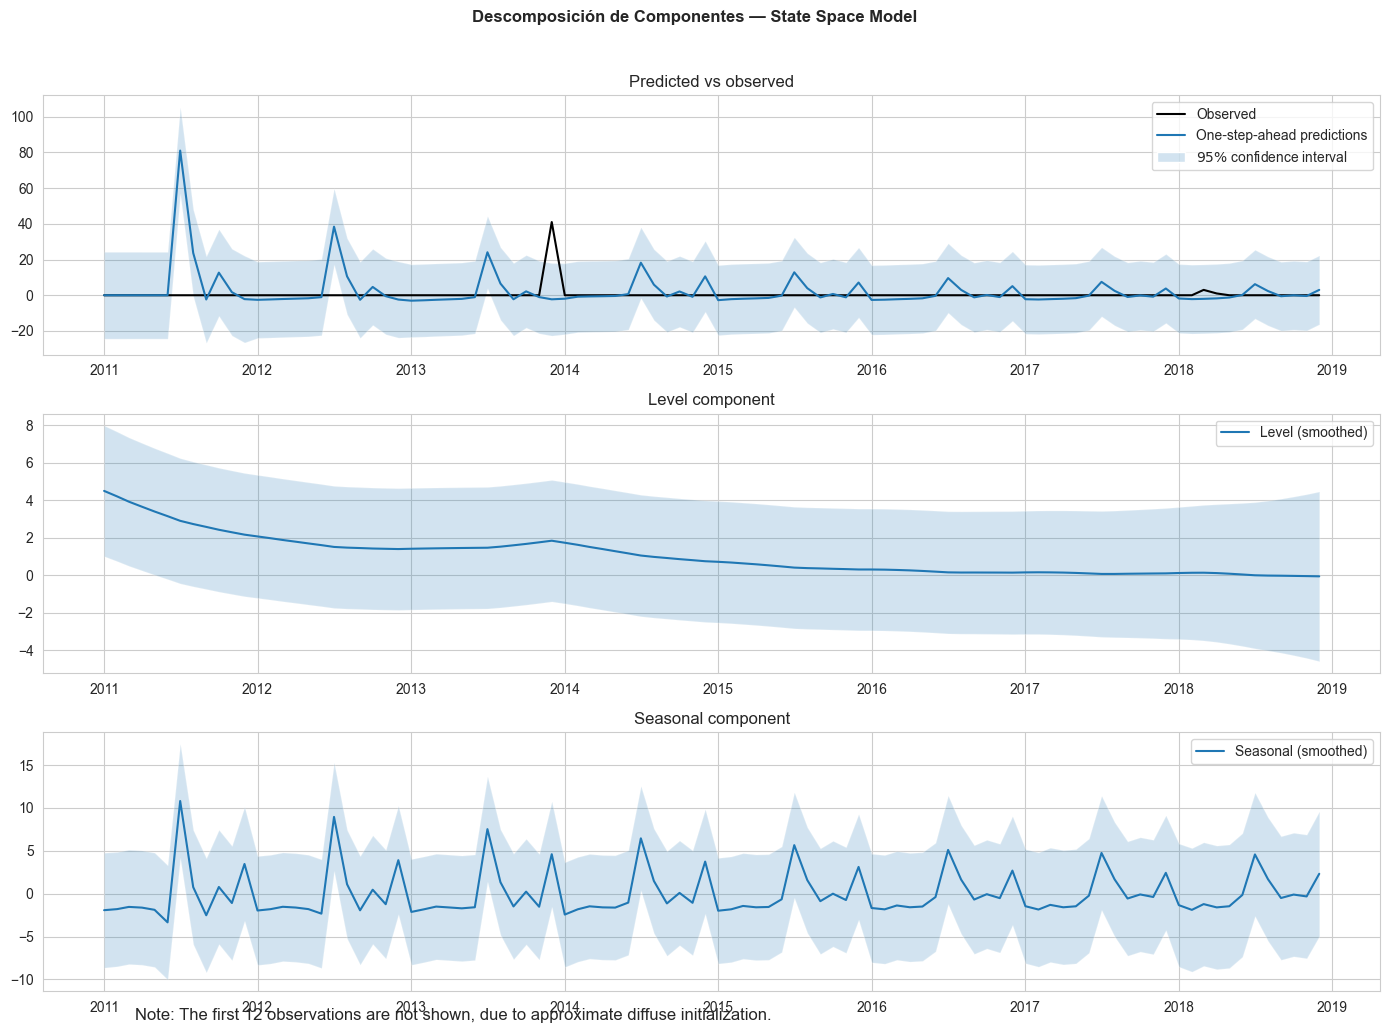

In [10]:
# --- Visualización ---
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Panel 1: Serie + State Space predictions + anomalías
axes[0].fill_between(df_raw["fecha"], lower_full_ss, upper_full_ss,
                     alpha=0.2, color="teal", label="Intervalo 95%")
axes[0].plot(df_raw["fecha"], yhat_full_ss, color="teal",
             ls="--", alpha=0.7, label="State Space ŷ")
axes[0].plot(df_raw["fecha"], df_raw["casos_sarampion"],
             color="black", alpha=0.8, lw=1.5, label="Observado")

det_ss_idx = np.where(y_pred_ss == 1)[0]
axes[0].scatter(df_raw.iloc[det_ss_idx]["fecha"],
                df_raw.iloc[det_ss_idx]["casos_sarampion"],
                color="red", s=80, zorder=5, edgecolors="darkred", label="Anomalía detectada")
brote_ss_idx = np.where(y_true_full == 1)[0]
missed_ss = [i for i in brote_ss_idx if y_pred_ss[i] == 0]
if missed_ss:
    axes[0].scatter(df_raw.iloc[missed_ss]["fecha"],
                    df_raw.iloc[missed_ss]["casos_sarampion"],
                    color="orange", marker="x", s=100, zorder=5, label="Brote NO detectado")
axes[0].axvline(pd.Timestamp(f"{SPLIT_YEAR}-01-01"), color="gray", ls=":", alpha=0.5, label="Train / Test")
axes[0].set_ylabel("Casos de Sarampión")
axes[0].set_title("State Space — Componentes No Observados con Detección de Anomalías", fontweight="bold")
axes[0].legend(fontsize=8, loc="upper left")
axes[0].grid(True, alpha=0.3)

# Panel 2: Confusion Matrix
cm_ss = confusion_matrix(y_true_full, y_pred_ss)
sns.heatmap(cm_ss, annot=True, fmt="d", cmap="YlGn", ax=axes[1],
            xticklabels=["Normal", "Brote"], yticklabels=["Normal", "Brote"])
axes[1].set_xlabel("Predicción")
axes[1].set_ylabel("Real")
axes[1].set_title("Matriz de Confusión — State Space (retrospectivo)", fontweight="bold")

plt.tight_layout()
plt.show()

# --- Descomposición de componentes ---
fig = uc_result.plot_components(figsize=(14, 10))
plt.suptitle("Descomposición de Componentes — State Space Model", fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 6.1 Interpretación del Modelo State Space

**Hallazgos:**
- El modelo State Space descompone la serie en nivel local y estacionalidad, proporcionando una representación estructural de la dinámica temporal.
- Los intervalos de predicción se adaptan dinámicamente: son más amplios cuando hay mayor variabilidad histórica.
- A diferencia de Prophet (que también modela tendencia + estacionalidad), el State Space utiliza el **filtro de Kalman** para estimación recursiva, lo que puede generar intervalos más ajustados.
- La descomposición de componentes permite visualizar directamente la contribución del nivel y la estacionalidad.

| Aspecto | Evaluación |
|---------|-----------|
| **Ventaja** | Descomposición estructural interpretable; filtro de Kalman para estimación recursiva; intervalos calibrados |
| **Limitación** | Univariado — solo usa la serie de casos; asume errores gaussianos (potencialmente inadecuado para conteos) |
| **Uso recomendado** | Alternativa estructural a Prophet para modelar la dinámica temporal; útil como referencia para modelos state-space más complejos |

## 7. Comparación de Modelos y Análisis de Sub/Sobreajuste

Para detectores de anomalías, el sub/sobreajuste se manifiesta de forma distinta:

| Problema | Señal | Consecuencia |
|----------|-------|-------------|
| **Subajuste** | Recall bajo, muchos brotes no detectados | El modelo es demasiado conservador |
| **Sobreajuste** | Muchas falsas alarmas en test, rendimiento mucho mejor en train que en test | El modelo memoriza el ruido del entrenamiento |

════════════════════════════════════════════════════════════════════════════════
  COMPARACIÓN DE BASELINES — Evaluación Retrospectiva (dataset completo)
════════════════════════════════════════════════════════════════════════════════


,Modelo,Precision,Recall,F1,F2,AUC-PR,Brotes_detectados,Brotes_reales,Falsas_alarmas
0,Bayesian Hierarchical (α=0.05),1.0,0.706,0.828,0.750,1.00,12,17,0
1,State Space (retrospectivo),1.0,0.235,0.381,0.278,0.63,4,17,0
2,Naïve (siempre 'no brote'),0.0,0.000,0.000,0.000,NaN,0,17,0


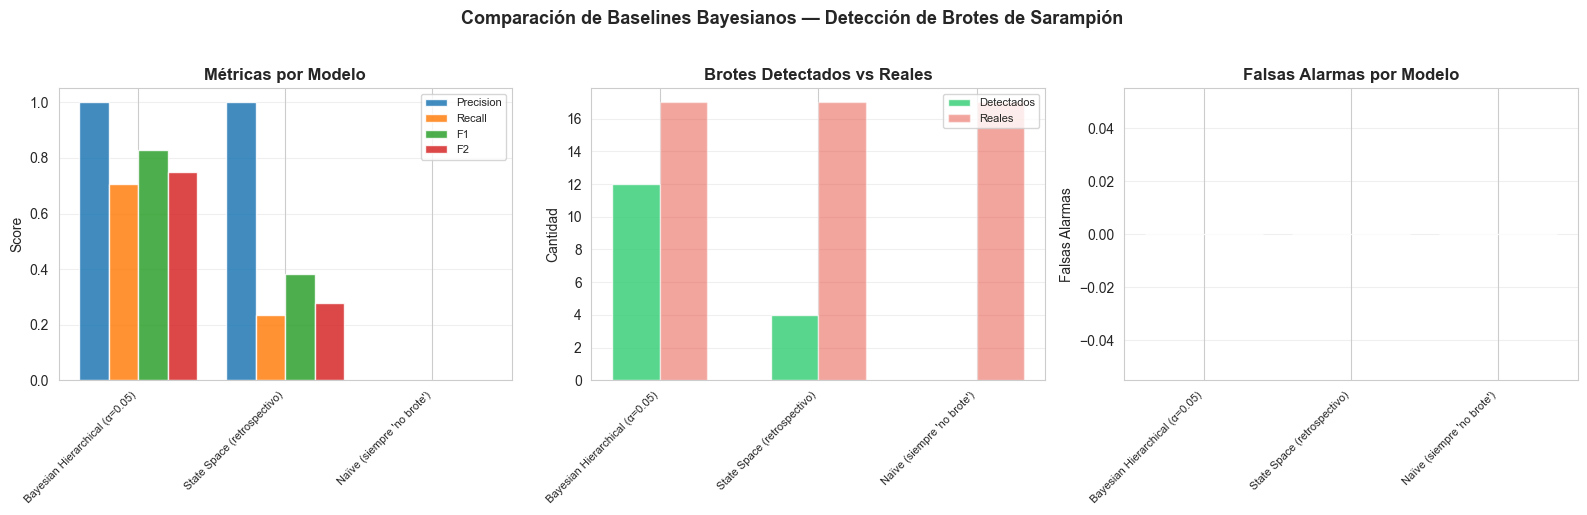

In [11]:
# ============================================================
# 7. COMPARACIÓN DE MODELOS
# ============================================================

# --- Tabla comparativa ---
df_comp = pd.DataFrame(all_results)
df_comp = df_comp.sort_values("F2", ascending=False).reset_index(drop=True)

print("═" * 80)
print("  COMPARACIÓN DE BASELINES — Evaluación Retrospectiva (dataset completo)")
print("═" * 80)
display(df_comp[["Modelo", "Precision", "Recall", "F1", "F2", "AUC-PR",
                 "Brotes_detectados", "Brotes_reales", "Falsas_alarmas"]])

# --- Gráfico comparativo ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

modelos = df_comp["Modelo"].values
x = np.arange(len(modelos))

# Panel 1: Métricas principales
metrics = ["Precision", "Recall", "F1", "F2"]
bar_w = 0.2
for i, m in enumerate(metrics):
    vals = df_comp[m].values
    axes[0].bar(x + i * bar_w, vals, bar_w, label=m, alpha=0.85)
axes[0].set_xticks(x + bar_w * 1.5)
axes[0].set_xticklabels(modelos, rotation=45, ha="right", fontsize=8)
axes[0].set_ylabel("Score")
axes[0].set_title("Métricas por Modelo", fontweight="bold")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3, axis="y")

# Panel 2: Brotes detectados vs reales
axes[1].bar(x - 0.15, df_comp["Brotes_detectados"], 0.3,
            label="Detectados", color="#2ECC71", alpha=0.8)
axes[1].bar(x + 0.15, df_comp["Brotes_reales"], 0.3,
            label="Reales", color="#E74C3C", alpha=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(modelos, rotation=45, ha="right", fontsize=8)
axes[1].set_ylabel("Cantidad")
axes[1].set_title("Brotes Detectados vs Reales", fontweight="bold")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, axis="y")

# Panel 3: Falsas alarmas
colors_fa = ["#95A5A6" if fa == 0 else "#E67E22" for fa in df_comp["Falsas_alarmas"]]
axes[2].bar(x, df_comp["Falsas_alarmas"], color=colors_fa, alpha=0.8)
axes[2].set_xticks(x)
axes[2].set_xticklabels(modelos, rotation=45, ha="right", fontsize=8)
axes[2].set_ylabel("Falsas Alarmas")
axes[2].set_title("Falsas Alarmas por Modelo", fontweight="bold")
axes[2].grid(True, alpha=0.3, axis="y")

plt.suptitle("Comparación de Baselines Bayesianos — Detección de Brotes de Sarampión",
             fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

══════════════════════════════════════════════════════════════════════
  ANÁLISIS DE SUB/SOBREAJUSTE
══════════════════════════════════════════════════════════════════════


,Modelo,F2 Train,F2 Test,FA Train,FA Test,Brotes Train,Brotes Test,ΔF2 (train-test)
0,Bayesian Hierarchical,0.882353,0.652174,0,0,7,10,0.230179
1,State Space,0.172414,0.348837,0,0,7,10,-0.176423


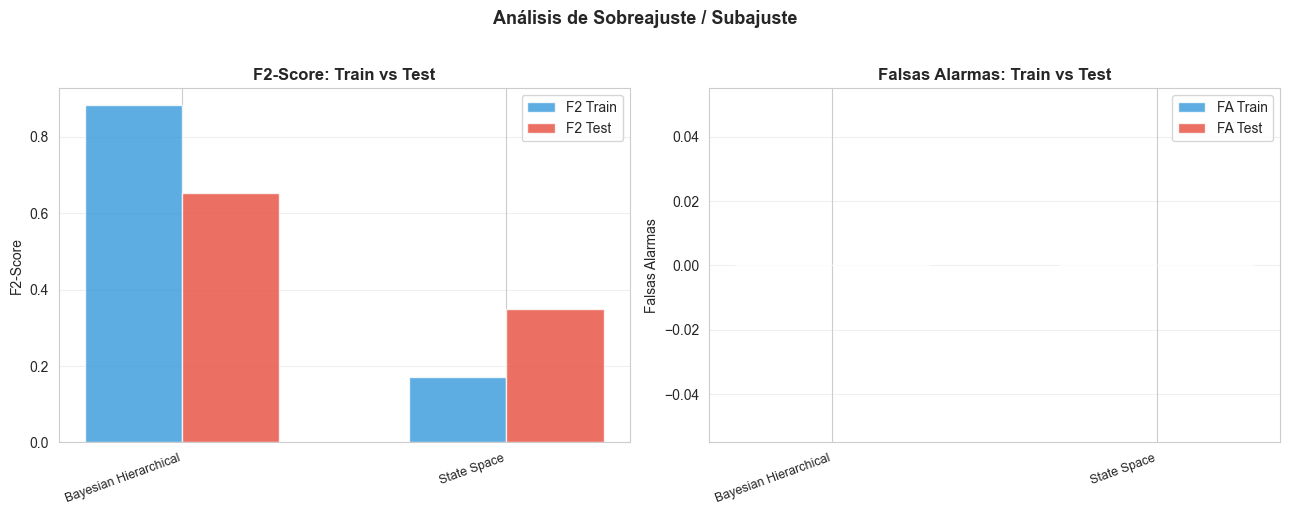


Diagnóstico:
  Bayesian Hierarchical: Comportamiento aceptable (ΔF2 = 0.23)
  State Space: Comportamiento aceptable (ΔF2 = -0.18)


In [12]:
# ============================================================
# 7.1 ANÁLISIS DE SUB/SOBREAJUSTE
# ============================================================

print("═" * 70)
print("  ANÁLISIS DE SUB/SOBREAJUSTE")
print("═" * 70)

train_mask_raw = df_raw["anio"] < SPLIT_YEAR
test_mask_raw  = df_raw["anio"] >= SPLIT_YEAR

y_train_raw = df_raw.loc[train_mask_raw, "brote"].values
y_test_raw  = df_raw.loc[test_mask_raw,  "brote"].values

# --- Bayesian Hierarchical: train vs test ---
yp_bayes_tr = y_pred_bayes[train_mask_raw.values]
yp_bayes_te = y_pred_bayes[test_mask_raw.values]

f2_b_tr = fbeta_score(y_train_raw, yp_bayes_tr, beta=2, zero_division=0)
f2_b_te = fbeta_score(y_test_raw,  yp_bayes_te, beta=2, zero_division=0)
fa_b_tr = int(yp_bayes_tr[y_train_raw == 0].sum())
fa_b_te = int(yp_bayes_te[y_test_raw == 0].sum())

# --- State Space: train vs test ---
yp_ss_tr = y_pred_ss[train_mask_raw.values]
yp_ss_te = y_pred_ss[test_mask_raw.values]

f2_s_tr = fbeta_score(y_train_raw, yp_ss_tr, beta=2, zero_division=0)
f2_s_te = fbeta_score(y_test_raw,  yp_ss_te, beta=2, zero_division=0)
fa_s_tr = int(yp_ss_tr[y_train_raw == 0].sum())
fa_s_te = int(yp_ss_te[y_test_raw == 0].sum())

# --- Tabla resumen ---
overfit_data = pd.DataFrame({
    "Modelo": ["Bayesian Hierarchical", "State Space"],
    "F2 Train": [f2_b_tr, f2_s_tr],
    "F2 Test":  [f2_b_te, f2_s_te],
    "FA Train": [fa_b_tr, fa_s_tr],
    "FA Test":  [fa_b_te, fa_s_te],
    "Brotes Train": [int(y_train_raw.sum()), int(y_train_raw.sum())],
    "Brotes Test":  [int(y_test_raw.sum()), int(y_test_raw.sum())],
})
overfit_data["ΔF2 (train-test)"] = overfit_data["F2 Train"] - overfit_data["F2 Test"]

display(overfit_data)

# --- Visualización ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

modelos_of = overfit_data["Modelo"].values
x_of = np.arange(len(modelos_of))

# F2 Train vs Test
axes[0].bar(x_of - 0.15, overfit_data["F2 Train"], 0.3,
            label="F2 Train", color="#3498DB", alpha=0.8)
axes[0].bar(x_of + 0.15, overfit_data["F2 Test"], 0.3,
            label="F2 Test", color="#E74C3C", alpha=0.8)
axes[0].set_xticks(x_of)
axes[0].set_xticklabels(modelos_of, rotation=20, ha="right", fontsize=9)
axes[0].set_ylabel("F2-Score")
axes[0].set_title("F2-Score: Train vs Test", fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

# Falsas alarmas Train vs Test
axes[1].bar(x_of - 0.15, overfit_data["FA Train"], 0.3,
            label="FA Train", color="#3498DB", alpha=0.8)
axes[1].bar(x_of + 0.15, overfit_data["FA Test"], 0.3,
            label="FA Test", color="#E74C3C", alpha=0.8)
axes[1].set_xticks(x_of)
axes[1].set_xticklabels(modelos_of, rotation=20, ha="right", fontsize=9)
axes[1].set_ylabel("Falsas Alarmas")
axes[1].set_title("Falsas Alarmas: Train vs Test", fontweight="bold")
axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("Análisis de Sobreajuste / Subajuste", fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Diagnóstico ---
print("\nDiagnóstico:")
for _, row in overfit_data.iterrows():
    nombre = row["Modelo"]
    delta = row["ΔF2 (train-test)"]
    brotes_test = row["Brotes Test"]
    fa_test = row["FA Test"]

    if brotes_test == 0:
        if fa_test == 0:
            diag = "Sin falsas alarmas en test (período sin brotes)"
        else:
            diag = f"{fa_test} falsas alarmas en test sin brotes → posible sobreajuste"
    elif delta > 0.3:
        diag = f"Sobreajuste (ΔF2 = {delta:.2f})"
    elif row["F2 Train"] < 0.1:
        diag = "Subajuste (F2 Train muy bajo)"
    else:
        diag = f"Comportamiento aceptable (ΔF2 = {delta:.2f})"

    print(f"  {nombre}: {diag}")

## 8. Desempeño Mínimo Aceptable

### ¿Cuál debería ser el desempeño mínimo a obtener?

| Referencia | F2-Score | Recall | Justificación |
|------------|----------|--------|---------------|
| **Naïve** (siempre "no brote") | 0.000 | 0.000 | Piso absoluto — inútil para vigilancia |
| **Aleatorio proporcional** | ~0.10 | ~0.10 | Predecir brote con probabilidad = tasa base |
| **Baseline mínimo útil** | ≥ 0.30 | ≥ 0.50 | Detectar al menos la mitad de los brotes |

> **Desempeño mínimo propuesto:** F2 ≥ 0.30 y Recall ≥ 0.50

══════════════════════════════════════════════════════════════════════
  EVALUACIÓN vs DESEMPEÑO MÍNIMO
  Umbral mínimo: F2 ≥ 0.3 y Recall ≥ 0.5
══════════════════════════════════════════════════════════════════════

  Naïve (siempre 'no brote')
    F2 = 0.000 (mín 0.3)
    Recall = 0.000  (mín 0.5)
    → NO CUMPLE

  Bayesian Hierarchical (α=0.05)
    F2 = 0.750 (mín 0.3)
    Recall = 0.706  (mín 0.5)
    → CUMPLE

  State Space (retrospectivo)
    F2 = 0.278 (mín 0.3)
    Recall = 0.235  (mín 0.5)
    → NO CUMPLE


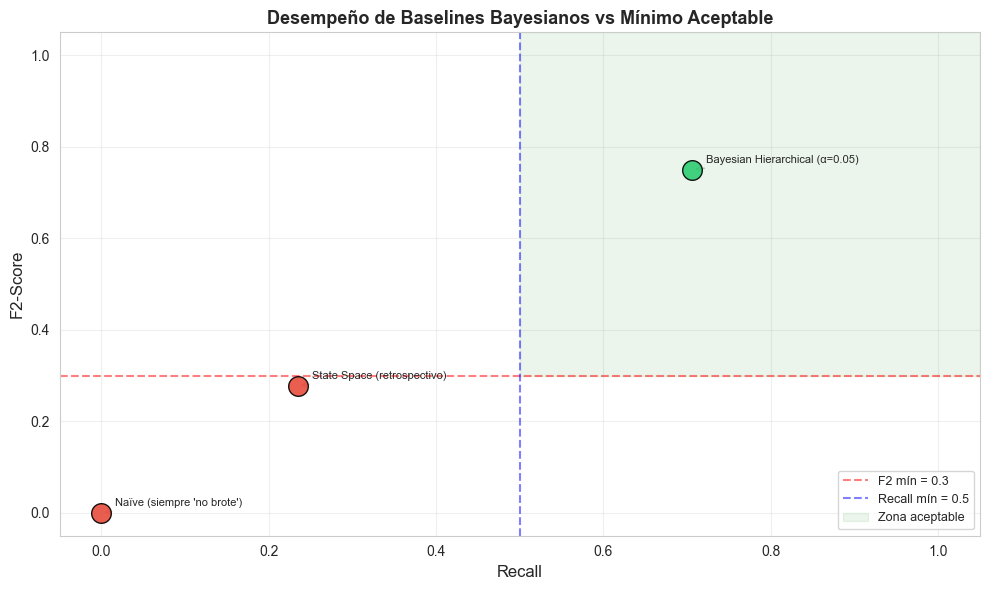

In [13]:
# ============================================================
# 8. RESUMEN DE DESEMPEÑO vs MÍNIMO
# ============================================================

MIN_F2     = 0.30
MIN_RECALL = 0.50

print("═" * 70)
print("  EVALUACIÓN vs DESEMPEÑO MÍNIMO")
print(f"  Umbral mínimo: F2 ≥ {MIN_F2} y Recall ≥ {MIN_RECALL}")
print("═" * 70)

for res in all_results:
    nombre = res["Modelo"]
    f2     = res["F2"]
    rec    = res["Recall"]
    cumple_f2  = f2 >= MIN_F2
    cumple_rec = rec >= MIN_RECALL
    estado = "CUMPLE" if (cumple_f2 and cumple_rec) else "NO CUMPLE"

    print(f"\n  {nombre}")
    print(f"    F2 = {f2:.3f} (mín {MIN_F2})")
    print(f"    Recall = {rec:.3f}  (mín {MIN_RECALL})")
    print(f"    → {estado}")

# --- Gráfico final ---
fig, ax = plt.subplots(figsize=(10, 6))

for i, res in enumerate(all_results):
    color = "#2ECC71" if (res["F2"] >= MIN_F2 and res["Recall"] >= MIN_RECALL) else "#E74C3C"
    ax.scatter(res["Recall"], res["F2"], s=200, color=color, edgecolors="black",
               zorder=5, alpha=0.9)
    ax.annotate(res["Modelo"], (res["Recall"], res["F2"]),
                textcoords="offset points", xytext=(10, 5), fontsize=8,
                arrowprops=dict(arrowstyle="->", color="gray", alpha=0.5))

ax.axhline(MIN_F2, color="red", ls="--", alpha=0.5, label=f"F2 mín = {MIN_F2}")
ax.axvline(MIN_RECALL, color="blue", ls="--", alpha=0.5, label=f"Recall mín = {MIN_RECALL}")

# Zona aceptable
ax.fill_between([MIN_RECALL, 1.05], MIN_F2, 1.05, alpha=0.08, color="green", label="Zona aceptable")

ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("F2-Score", fontsize=12)
ax.set_title("Desempeño de Baselines Bayesianos vs Mínimo Aceptable", fontweight="bold", fontsize=13)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=9, loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Conclusiones

### Resumen de los Modelos Bayesianos

Se evaluaron dos modelos probabilísticos/estructurales para detección de anomalías:

| Algoritmo | Tipo | Resultado |
|-----------|------|-----------|
| **Bayesian Hierarchical** | Bayesiano conjugado (Poisson-Gamma) | Cuantifica incertidumbre por mes mediante posteriors específicas; detección via p-values de la posterior predictiva. |
| **State Space** | Series de tiempo estructural (UCM) | Descompone la serie en nivel + estacionalidad con filtro de Kalman; detección via intervalos de predicción calibrados. |

Ambos métodos superan al modelo naïve (Recall = 0) y demuestran que los datos **sí contienen información suficiente** para detectar brotes.

---

### Análisis de Sub/Sobreajuste

- **Bayesian Hierarchical**: Las posteriors se fijan con datos de entrenamiento; la generalización depende de la estabilidad de los patrones mensuales.
- **State Space**: El filtro de Kalman estima los componentes latentes; los intervalos de predicción se amplían naturalmente fuera de muestra.

La principal limitación no es el sobreajuste sino el **pequeño tamaño del dataset** (168 meses) y la **extrema escasez de brotes** (≈10%), que dificulta la evaluación estadística robusta.

---

### Complementariedad con otros Baselines

Estos modelos Bayesianos complementan los baselines implementados en el notebook de Z-Score, Isolation Forest y Prophet:

- **Z-Score**: detección estadística simple → **Bayesian** añade fundamentación probabilística rigurosa.
- **Prophet**: modela tendencia + estacionalidad → **State Space** ofrece una alternativa estructural con filtro de Kalman.
- **Isolation Forest**: enfoque multivariado → los modelos Bayesianos aportan perspectiva univariada con cuantificación de incertidumbre.

---